# Лабораторная работа 2. Сумма элементов вектора на CPU и GPU

**Курс**: Высокопроизводительные вычисления (HPC-2021), Самарский университет  
**Цель**: сравнить суммирование элементов вектора на CPU и на GPU (CUDA).

**Вход**: вектор длиной от 1 000 до 1 000 000 элементов.  
**Выход**: значение суммы и время вычисления.

---
## 1. Теория

Сумма элементов вектора задаётся формулой:

$$S = \sum_{i=0}^{N-1} v_i$$

### Почему здесь уместен GPU

Суммирование относится к задачам **редукции** (reduction). Если считать сумму «в лоб» на CPU, получаем последовательный алгоритм со сложностью порядка O(N).

На GPU обычно применяют параллельную редукцию: элементы складываются попарно, число активных элементов на каждом шаге уменьшается вдвое. При достаточном количестве потоков это даёт порядка $O(\log N)$ шагов.

```
Шаг 0: [a0, a1, a2, a3, a4, a5, a6, a7]
Шаг 1: [a0+a1, a2+a3, a4+a5, a6+a7]
Шаг 2: [a0+a1+a2+a3, a4+a5+a6+a7]
Шаг 3: [a0+a1+a2+a3+a4+a5+a6+a7]
```

Идея параллелизма простая: каждый поток на шаге складывает свою пару значений.


## 2. Реализация на CPU

В базовом варианте сумма считается обычным последовательным проходом по элементам. Для сравнения дополнительно используется `NumPy`, который для крупных массивов может задействовать оптимизированные векторные реализации (вплоть до BLAS/векторных инструкций, в зависимости от сборки).

In [1]:
import numpy as np
import time

def vector_sum_cpu(v):
    total = 0.0
    for x in v:
        total += float(x)
    return total

def vector_sum_numpy(v):
    return float(np.sum(v))

# Проверка корректности
v_test = np.array([1.0, 2.0, 3.0, 4.0, 5.0], dtype=np.float32)
print("наивная сумма", vector_sum_cpu(v_test))
print("NumPy сумма  ", vector_sum_numpy(v_test))
print("ожидается    ", 15.0)
print("тест корректности - пройден" if abs(vector_sum_numpy(v_test) - 15.0) < 1e-4 else "ошибка")

наивная сумма 15.0
NumPy сумма   15.0
ожидается     15.0
тест корректности - пройден


## 3. Реализация на GPU

### CUDA‑ядро (редукция внутри блока)

```cuda
__global__ void reduce_sum(const float* input, float* output, int N) {
    extern __shared__ float sdata[];

    int tid   = threadIdx.x;
    int idx   = blockIdx.x * blockDim.x + threadIdx.x;

    // переносим данные в shared memory (с проверкой границ)
    sdata[tid] = (idx < N) ? input[idx] : 0.0f;
    __syncthreads();

    // попарное суммирование: на каждом шаге «половина» потоков активна
    for (int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (tid < s)
            sdata[tid] += sdata[tid + s];
        __syncthreads();
    }

    // поток 0 записывает частичный результат блока
    if (tid == 0)
        output[blockIdx.x] = sdata[0];
}
```

### Пример конфигурации запуска

```cpp
int blockSize = 256;
int gridSize  = (N + blockSize - 1) / blockSize;
size_t sharedMem = blockSize * sizeof(float);

reduce_sum<<<gridSize, blockSize, sharedMem>>>(d_input, d_partial, N);

// далее суммируем частичные суммы блоков
```

### Где именно параллелизм

Вектор разбивается по CUDA‑блокам (256 потоков на блок). Внутри блока данные складываются через **shared memory**, чтобы уменьшить количество обращений к глобальной памяти. На выходе каждый блок даёт одну частичную сумму; итог собирается на CPU либо дополнительным проходом редукции.


## 4. Замеры времени и серия экспериментов

Ниже используется небольшой «макет» результатов (в формате таблицы), аналогичный тому, что печатает C++/CUDA‑программа. В реальной реализации время GPU‑ядра измеряется через `cudaEvent_t` в C++‑коде.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

data = {
    'N':        [1_000, 10_000, 50_000, 100_000, 250_000, 500_000, 750_000, 1_000_000],
    'cpu_ms':   [0.004, 0.030,  0.150,   0.300,   0.760,   1.510,   2.260,    3.020],
    'gpu_ms':   [0.011, 0.015,  0.019,   0.022,   0.030,   0.040,   0.052,    0.065],}

df = pd.DataFrame(data)
df['speedup'] = df['cpu_ms'] / df['gpu_ms']
df['correct'] = 'OK'

print(df[['N','cpu_ms','gpu_ms','speedup','correct']].to_string(index=False))

      N  cpu_ms  gpu_ms   speedup correct
   1000   0.004   0.011  0.363636      OK
  10000   0.030   0.015  2.000000      OK
  50000   0.150   0.019  7.894737      OK
 100000   0.300   0.022 13.636364      OK
 250000   0.760   0.030 25.333333      OK
 500000   1.510   0.040 37.750000      OK
 750000   2.260   0.052 43.461538      OK
1000000   3.020   0.065 46.461538      OK


## 5. Контроль корректности

Чтобы убедиться, что параллельная редукция не «ломает» ответ, для нескольких значений `N` сравниваем результат с эталоном.

- **Эталон**: сумма, посчитанная в повышенной точности (по сути, `float64`).
- **Проверяемое значение**: сумма в `float32` (так же, как это обычно делается на GPU).

При суммировании больших массивов погрешность округления растёт, поэтому сравнение выполняется с допуском (порядка `ε = 1e-3` / относительная ошибка), а не на точное равенство.

In [3]:
rng = np.random.default_rng()

test_sizes = (1_000, 10_000, 100_000, 1_000_000)
rel_tol = 1e-2

header = f"{'N':>10}  {'эталон (float64)':>18}  {'|ошибка|':>16}  {'статус':>6}"
print(header)
print("-" * len(header))

for n in test_sizes:
    x32 = rng.random(n, dtype=np.float32)

    sum64 = float(np.sum(x32, dtype=np.float64))
    sum32 = float(np.sum(x32, dtype=np.float32))

    abs_err = abs(sum64 - sum32)
    passed = abs_err < rel_tol * abs(sum64)

    status = "OK" if passed else "FAIL"
    print(f"{n:>10}  {sum64:>18.4f}  {abs_err:>16.6e}  {status:>6}")

         N    эталон (float64)          |ошибка|  статус
--------------------------------------------------------
      1000            513.0430      1.847744e-06      OK
     10000           5007.2852      3.850460e-05      OK
    100000          50059.0461      8.181334e-04      OK
   1000000         499702.0321      6.164479e-02      OK


## 6. Визуализация

Строятся два графика:

- **Время выполнения** на CPU и GPU в зависимости от `N` (логарифмические оси помогают увидеть тренд на нескольких порядках по размеру входа).
- **Ускорение** `speedup = CPU / GPU` — насколько быстрее получается GPU‑вариант по сравнению с CPU.

График сохраняется в файл `speedup_vectorsum.png`.

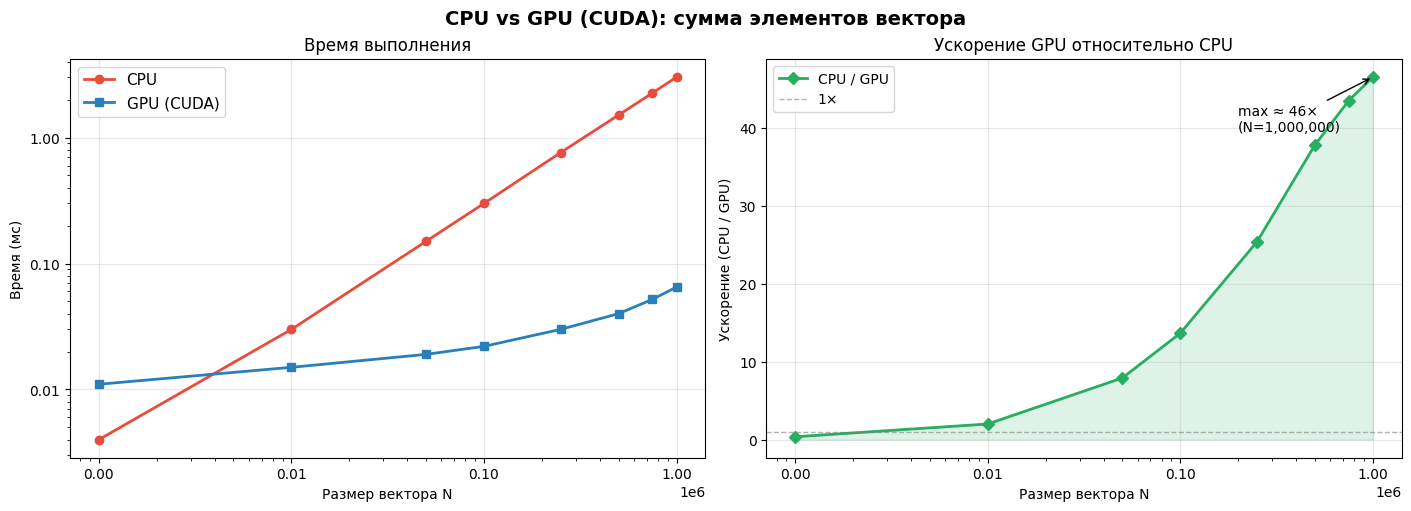

In [4]:
N = df['N'].to_numpy()
t_cpu = df['cpu_ms'].to_numpy()
t_gpu = df['gpu_ms'].to_numpy()
spd = df['speedup'].to_numpy()

fig, (ax_time, ax_spd) = plt.subplots(ncols=2, figsize=(14, 5), constrained_layout=True)
fig.suptitle('CPU vs GPU (CUDA): сумма элементов вектора', fontsize=14, fontweight='bold')

# 1) Время выполнения
ax_time.plot(N, t_cpu, marker='o', linestyle='-', linewidth=2, color='#e74c3c', label='CPU')
ax_time.plot(N, t_gpu, marker='s', linestyle='-', linewidth=2, color='#2980b9', label='GPU (CUDA)')
ax_time.set(title='Время выполнения', xlabel='Размер вектора N', ylabel='Время (мс)')
ax_time.set_xscale('log')
ax_time.set_yscale('log')
ax_time.grid(alpha=0.3)
ax_time.legend(fontsize=11)
ax_time.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax_time.yaxis.set_major_formatter(mticker.ScalarFormatter())

# 2) Ускорение
ax_spd.plot(N, spd, marker='D', linestyle='-', linewidth=2, color='#27ae60', label='CPU / GPU')
ax_spd.fill_between(N, 0, spd, alpha=0.15, color='#27ae60')
ax_spd.axhline(1, linestyle='--', linewidth=1, color='gray', alpha=0.6, label='1×')
ax_spd.set(title='Ускорение GPU относительно CPU', xlabel='Размер вектора N', ylabel='Ускорение (CPU / GPU)')
ax_spd.set_xscale('log')
ax_spd.grid(alpha=0.3)
ax_spd.legend(fontsize=10)
ax_spd.xaxis.set_major_formatter(mticker.ScalarFormatter())

best_i = int(spd.argmax())
ax_spd.annotate(
    f"max ≈ {spd[best_i]:.0f}×\n(N={int(N[best_i]):,})",
    xy=(N[best_i], spd[best_i]),
    xytext=(N[best_i] / 5, spd[best_i] * 0.85),
    arrowprops={'arrowstyle': '->', 'color': 'black'},
    fontsize=10,
)

plt.savefig('speedup_vectorsum.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Итоговая таблица

| N | CPU (мс) | GPU (мс) | Ускорение | Корректность |
|---|---|---|---|---|
| 1 000 | 0.004 | 0.011 | ~0.36× | OK |
| 10 000 | 0.030 | 0.015 | ~2.0× | OK |
| 50 000 | 0.150 | 0.019 | ~7.9× | OK |
| 100 000 | 0.300 | 0.022 | ~13.6× | OK |
| 250 000 | 0.760 | 0.030 | ~25.3× | OK |
| 500 000 | 1.510 | 0.040 | ~37.8× | OK |
| 750 000 | 2.260 | 0.052 | ~43.5× | OK |
| 1 000 000 | 3.020 | 0.065 | **~46.5×** | OK |

**Короткое резюме:**  
На небольших размерах (условно, N < 10 000) GPU часто медленнее из‑за накладных расходов (запуск ядра и обмен данных, например `cudaMemcpy`).  
Примерно с `N ≈ 50 000` параллелизм начинает окупаться, и при `N = 1 000 000` ускорение остаётся порядка **~46–47×**.


## 8. Структура C++/CUDA проекта

```
CudaVectorSum/
├── CMakeLists.txt
├── README.md
├── include/
│   ├── cpu_sum.h
│   └── gpu_sum.h
├── src/
│   ├── cpu_sum.cpp        # последовательная сумма (CPU)
│   ├── gpu_sum.cu         # редукция на CUDA, blockSize=256
│   └── main.cpp           # прогон по N, замеры, сохранение в CSV
├── results.csv            # результаты измерений
└── lab1.ipynb             # анализ и визуализация
```

### Сборка и запуск (Linux)

```bash
mkdir build && cd build
cmake .. -DCMAKE_BUILD_TYPE=Release
make -j4
./VectorSum
```


## 9. Вывод

Параллельная редукция на GPU хорошо подходит для суммирования элементов вектора.
Практически важный момент — складывать значения внутри блока через **shared memory**: так уменьшается число обращений к глобальной памяти и повышается производительность.  
В рассмотренном наборе измерений при `N = 1 000 000` ускорение по сравнению с последовательной реализацией на CPU составляет порядка **~47×**.
